## 2025-03-03: CNN Exploraiton

### Authors
* Nicole Tin (nicole@velexi.com)


### Overview
This Jupyter notebook is intended to explore

* various packages/architectures for constructing a CNN to use on images

### Key Results

The key results of this experiment are ...

### Future Ideas
* document feature engineering (citations) and model steps
* screenshot
* debug CNN and AutoML
* migrate to standard input, file as input
* file path as input : function pipeline is more stable


### Experiment Parameters

In [2]:
# --- Experiment parameters

# Name of experiment. Used for MLflow experiment name, output files, etc.
experiment_name = "NT-M4-Tensorflow"

# Paths
root = '/Users/ntin/Documents/DermaML_local/hawkeye-hands-2024-07-29'

image_folder = '/images_processed/'
features_folder = '/features-2025-02-24/'
csv_file = '/metadata.csv'

# ------ Algorithm parameters

# train/test split
split = 0.7
epochs = 10
learning_rate = 1e3

### Preparations

In [3]:
# --- Imports

# Internal library
from dermaml.data import read_local

# Standard library
import random 
import math
from datetime import datetime
# External packages
import matplotlib.pyplot as plt
import numpy as np
import cv2 as cv
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models

# Entropy
random.seed(42)
np.random.seed(42)

np.set_printoptions(precision=3, suppress=True)

In [4]:
metadata = pd.read_csv(root+ csv_file)
metadata.loc[:, 'Age'] = 2024-metadata['birth_year']
valid_image_fnames_df = pd.DataFrame(metadata.set_index('Age').loc[:, ['right_hand_image_file', 'left_hand_image_file']].stack()).reset_index()
valid_image_fnames_df.columns = ['Age', 'handedness', 'filename']
valid_image_fnames_df.loc[:,'filename'] = valid_image_fnames_df['filename'].apply(lambda x: x[:-5])
valid_image_fnames = valid_image_fnames_df['filename'].to_numpy()

### Read Images

In [5]:
samples, hawkeye_filenames = read_local(root+image_folder)
image_count = len(hawkeye_filenames)

 14%|█▍        | 83/577 [00:21<02:07,  3.86it/s]

.DS_Store


100%|██████████| 577/577 [02:30<00:00,  3.84it/s]


In [9]:
import pickle
p_path = '/Users/ntin/Models/sam2/notebooks/'
corrected_segmentations = '2025-02-23_Hand_Segmentations-Corrected-3.pkl'

with open(p_path+corrected_segmentations, 'rb') as file:
    segmentations = pickle.load(file)

In [10]:
def square_resize(im, mask=None):
    '''
    Fit an image to a (512, 512) square by first padding the image
    _______
    
    Returns: Image of shape(512, 512, 3)
    '''

    if mask is not None:
        im = np.where(mask[..., None], im, 0)

    # calculate padding distance
    h, w, c = im.shape
    side = max(w, h)
    delta_w = side-w
    delta_h = side-h
    top, bottom = delta_h//2, delta_h-(delta_h//2)
    left, right = delta_w//2, delta_w-(delta_w//2)

    # add 0 border
    square = cv.copyMakeBorder(im, top, bottom, left, right, cv.BORDER_CONSTANT,value=0)

    # reshape to size (512, 512)
    norm_square = cv.resize(square, (512, 512))

    return norm_square

In [11]:
X, y = [], []
for i in range(len(hawkeye_filenames)):
    fname = hawkeye_filenames[i]
    root = fname.split('.')[0]

    # define X value
    im = samples[fname]
    mask = segmentations[root]
    norm_square = square_resize(im, mask)

    # define y 
    instance = valid_image_fnames_df[valid_image_fnames_df['filename'] == root]

    X += [norm_square]
    y += [instance.Age.values]


X, y = np.array(X), np.array(y)

In [12]:
y

array([[ 21],
       [ 21],
       [ 40],
       [ 20],
       [ 26],
       [ 30],
       [ 38],
       [ 73],
       [ 23],
       [ 27],
       [ 81],
       [ 65],
       [100],
       [ 61],
       [ 32],
       [ 28],
       [ 55],
       [ 55],
       [ 20],
       [ 48],
       [ 58],
       [ 22],
       [ 67],
       [ 94],
       [ 27],
       [ 39],
       [ 97],
       [ 18],
       [ 90],
       [ 26],
       [ 66],
       [ 53],
       [ 67],
       [ 36],
       [ 38],
       [ 52],
       [ 34],
       [ 74],
       [ 25],
       [ 47],
       [ 51],
       [ 73],
       [ 73],
       [ 90],
       [ 61],
       [ 29],
       [ 72],
       [ 32],
       [ 97],
       [ 67],
       [ 65],
       [ 83],
       [ 62],
       [ 22],
       [ 72],
       [ 71],
       [ 22],
       [ 89],
       [ 95],
       [ 43],
       [ 93],
       [ 58],
       [ 71],
       [ 20],
       [ 20],
       [ 91],
       [ 51],
       [ 45],
       [ 50],
       [ 20],
       [ 83],
      

In [13]:
train_size = math.floor(image_count * split)
# train_dataset = image_data[:train_size]
# test_dataset = image_data[train_size:]
x_train = np.array(X[:train_size])
x_test = np.array(X[train_size:])

# round labels to neearest fifth
y_train = np.around(y[:train_size]/5, decimals=0)*5
y_test = np.around(y[train_size:]/5, decimals=0)*5

y_train = y_train.astype(np.float32)
y_test = y_test.astype(np.float32)

print(x_train.shape, y_train.shape)  # Expected: (403, 512, 512, 3) and (403, 1)
print(x_test.shape, y_test.shape)    # Expected: (N, 512, 512, 3) and (N, 1)

test_results = {}

(403, 512, 512, 3) (403, 1)
(173, 512, 512, 3) (173, 1)


### Perform computational experiment

In [14]:
model = models.Sequential()

k = 5
# First Convolutional Layer
model.add(layers.Conv2D(32, (k, k), activation='relu', input_shape=(512, 512, 3)))
model.add(layers.MaxPooling2D((2, 2)))

# Second Convolutional Layer
model.add(layers.Conv2D(64, (k, k), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

# Third Convolutional Layer
model.add(layers.Conv2D(64, (k, k), activation='relu'))

# Flatten the output and add Dense layers
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dropout(0.5))
model.add(layers.Dense(1, activation='linear'))

/Users/ntin/DermaML/.venv/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [15]:
model.compile(optimizer='adam',
              loss='mse',
              metrics=['mae'])

In [16]:
print(x_train.shape, y_train.shape)  # Expected: (403, 512, 512, 3) and (403, 1)
print(x_test.shape, y_test.shape)    # Expected: (N, 512, 512, 3) and (N, 1)


(403, 512, 512, 3) (403, 1)
(173, 512, 512, 3) (173, 1)


In [17]:
print(x_train.dtype, y_train.dtype)  # Should both be float32
print(x_test.dtype, y_test.dtype)    # Should both be float32


float32 float32
float32 float32


In [18]:
history = model.fit(x_train, y_train, epochs=10, batch_size=32,
                    validation_data=(x_test, y_test))

Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 34s 3s/step - loss: 3621.5098 - mae: 46.0163 - val_loss: 3406.8584 - val_mae: 19.5261
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 34s 3s/step - loss: 935.7395 - mae: 19.7332 - val_loss: 3378.0962 - val_mae: 21.0376
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 34s 3s/step - loss: 839.3076 - mae: 18.8102 - val_loss: 3641.8494 - val_mae: 28.3582
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 34s 3s/step - loss: 1060.0536 - mae: 22.1089 - val_loss: 3498.2871 - val_mae: 25.4043
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 34s 3s/step - loss: 1195.5909 - mae: 22.8462 - val_loss: 3261.3621 - val_mae: 22.3469
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 34s 3s/step - loss: 2240.2307 - mae: 22.5317 - val_loss: 3606.8186 - val_mae: 19.7651
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 34s 3s/step - loss: 1060.5078 - mae: 17.2656 - val_loss: 3323.3059 - val_mae: 19.9144
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 34s 3s/step - loss: 1898.4191 - mae: 19.3548 - val_loss: 3277.7434 - val_mae: 19.2414
Epoch 9/10

In [19]:
test_loss, test_mae = model.evaluate(x_test, y_test, verbose=2)
print(f'\nTest MAE: {test_mae}')

6/6 - 3s - 541ms/step - loss: 3723.5747 - mae: 21.3615

Test MAE: 21.361488342285156


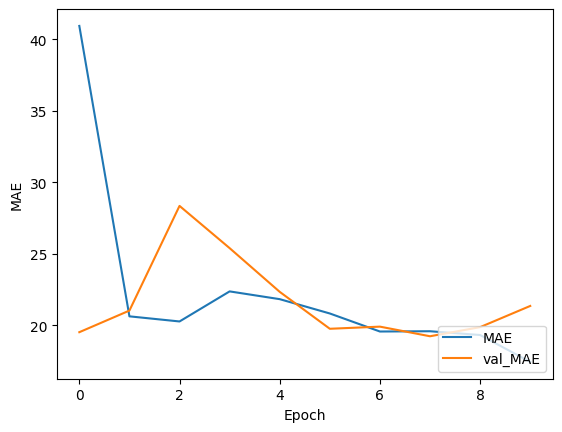

In [20]:
plt.plot(history.history['mae'], label='MAE')
plt.plot(history.history['val_mae'], label = 'val_MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend(loc='lower right')
plt.show()

In [21]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 508, 508, 32)   │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 254, 254, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 250, 250, 64)   │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 125, 125, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 121, 121, 64)   │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 937024)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │    59,969,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 180,377,477 (688.09 MB)

 Trainable params: 60,125,825 (229.36 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 120,251,652 (458.72 MB)